## Parallel AMS/AMSA

In [37]:
import numpy as np
def prune_threads(l):
    '''
    Description:
        Removes adjacent threads that are within a threshold of 2 for amsa algorithm
    Inputs:
        l: number of heavy hitters
    '''
    i = 0 # index variable
    while (i < len(threads_vec_amsa)):
        # boundary check
        if (i >= len(threads_vec_amsa) - 2):
            return
        t_i = threads_vec_amsa[i] # thread identity
        
        rest_est_ti = np.sqrt(np.median(hist_amsa[t_i][l:]**2))
        temp_ti = np.concatenate((hist_amsa[t_i][:l], [rest_est_ti])) 
        ams_ti = np.linalg.norm(temp_ti, 2) # amsa estimate for thread
        
        t_i2 = threads_vec_amsa[i+2] # adjcaent thread
        rest_est_ti2 = np.sqrt(np.median(hist_amsa[t_i2][l:]**2))
        temp_ti2 = np.concatenate((hist_amsa[t_i2][:l], [rest_est_ti2])) 
        ams_ti2 = np.linalg.norm(temp_ti2, 2) # amsa estimate for adjacent thread
        # check distance, prune hist, threads
        denom = min(ams_ti, ams_ti2)
        if (denom != 0 and (max(ams_ti, ams_ti2)/denom <= 2)):
            # remove the thread in between
            t_i1 = threads_vec_amsa[i+1]
            threads_vec_amsa.pop(i+1)
            hist_amsa.pop(t_i1)
            hist_ams.pop(t_i1)
            i -= 1
        i += 1

In [38]:
import numpy as np
def spawn_threads(timestep, buckets, l, r):
    '''
    Description:
        Helper function to spawn threads for AMSA
    Inputs:
        timestep: timestep identifier for new thread
        buckets: number of buckets
        l: number of heavy hitters
        r: number of repetitions
    '''
    if (len(threads_vec_amsa) == num_threads_max):
        prune_threads(l)
    if (len(threads_vec_amsa) < num_threads_max):
        # spawn a new thread
        threads_vec_amsa.append(timestep)
        hist_amsa[timestep] = np.zeros(buckets)
        hist_ams[timestep] = np.zeros(r)

In [39]:
import csv
import ipaddress
from utils import hash_func
def parallel_ams_amsa_from_file(heavy, filepath, limit, r):
    '''
    Description:
        Runs smooth histogram amsa algorithm on IP addresses
    Inputs:
        heavy: list of heavy hitter IP addresses
        filepath: file to run algorithm on
        limit: number of addresses to process
        r: number of algorithm repetitions
    Outputs:
        histogram of estimated 2 norms of frequency vector
    '''
    
    l = len(heavy)
        
    with open(filepath) as csvfile:
        stream = csv.reader(csvfile, delimiter=',')
        stream.__next__() # get rid of the header
        time = 1
        for row in stream:
            if (stream.line_num == limit):
                break
            try:
                s_i = int(ipaddress.ip_address(row[0]))
            except:
                # not an IPv4 or IPv6 address
                continue
            timestep = time
            time += 1
            # print(timestep)
            vals.append(s_i)
            try:
                index = heavy.index(s_i)
                # s_i is a heavy hitter
                spawn_threads(timestep, l+r, l, r)
                # update all existing threads
                for t_i in threads_vec_amsa:
                    hist_amsa[t_i][index] += 1
                    # update the ams stack
                    for i in range(r):
                        v_i = 2*hash_func(i, s_i, 2) - 1
                        hist_ams[t_i][i] += v_i
            except ValueError:
                # s_i is not a heavy hitter
                spawn_threads(timestep, l+r, l, r)
                # update all existing threads
                for t_i in threads_vec_amsa:
                    for i in range(r):
                        v_i = 2*hash_func(i, s_i, 2) - 1
                        hist_amsa[t_i][l+i] += v_i
                        hist_ams[t_i][i] += v_i    

## Test Parallel AMS/AMSA on Data

In [40]:
# from CS
hh_cs = [2401796176,
 3573875943,
 879396542,
 1572803056,
 3451786411,
 1298962670,
 607033987,
 2497912303,
 3339135037,
 887074222,
 1115991985,
 2613392396,
 1604957565,
 1072021340,
 2987213905,
 3124349474,
 3124349526,
 517524860,
 595152676,
 3568914218,
 2839797836,
 1039166085,
 1115974613,
 3174560376,
 3124327772,
 3016127925]

In [41]:
# from gpt
hh_gpt = [
    
]

In [42]:
hh_gemini = ['93.191.17.217', 
                '66.132.107.213', 
                '186.57.202.86', 
                '163.104.156.57', 
                '213.5.4.231', 
                '212.185.79.42', 
                '186.57.117.92', 
                '84.115.156.13', 
                '205.190.20.171', 
                '16.25.141.229', 
                '117.152.100.47', 
                '205.190.27.212', 
                '186.57.117.104', 
                '26.69.40.26', 
                '169.91.106.25', 
                '95.169.181.125', 
                '66.132.175.177', 
                '148.227.28.170', 
                '148.227.29.239', 
                '52.193.94.101', 
                '189.55.242.120', 
                '192.75.167.251', 
                '114.56.97.199', 
                '211.148.179.99', 
                '117.164.144.24', 
                '45.227.253.244', 
                '55.28.201.238', 
                '203.108.167.37', 
                '178.13.68.81', 
                '195.188.138.42', 
                '198.171.21.225', 
                '146.55.124.107', 
                '218.183.129.45', 
                '71.186.208.112', 
                '52.223.173.174', 
                '148.227.42.103', 
                '205.190.20.136', 
                '77.108.152.238', 
                # '2158:2b7e:e7f0:7f07', 
                '25.51.107.120', 
                '93.85.164.193', 
                '30.220.161.68', 
                '66.146.187.182', 
                '148.227.29.238', 
                '30.45.186.91', 
                '124.25.147.70', 
                '93.191.17.240', 
                '143.40.128.80', 
                '16.136.231.190', 
                '169.107.218.97', 
                '169.148.229.197', 
                '52.21.84.89'
                ]
hh_gemini = [int(ipaddress.ip_address(ip)) for ip in hh_gemini]

In [43]:
hist_ams = {}
hist_amsa = {}
threads_vec_amsa = []
num_threads_max = 20
vals = []
m=int(1e6)
parallel_ams_amsa_from_file(heavy=hh_gemini, 
                            filepath="CAIDA/125910_ip_timestamps.csv",
                            limit=m,
                            r=11)

## Visualize AMSA Results

In [44]:
import numpy as np
def calculate_estimates(hist_ams, hist_amsa):
    '''
    Description:
        Helper function to calcualte estimates for ams and amsa
    Inputs:
        hist_ams: ams histogram values
        hist_amsa: amsa histogram values
    Returns:
        indices: unpruned amsa timesteps
        est_amsa: corresponding amsa histogram estimates
        est_amsa: corresponding ams histogram estimates
        gts: ground truth norm values
        err_amsa: amsa to ground truth ratios
        err_ams: ams to ground truth ratios
    '''
    
    # calculate amsa estimates
    indices = []
    est_amsa = []
    l = len(hh_gemini)
    
    for time, norms in hist_amsa.items():
        indices.append(time)
        rest_est_ti = np.sqrt(np.median(norms[l:]**2))
        temp_ti = np.concatenate((norms[:l], [rest_est_ti])) 
        ams_ti = np.linalg.norm(temp_ti, 2)
        est_amsa.append(ams_ti)

    # calculate ams estimates
    est_ams = []

    for _, norms in hist_ams.items():
        est_ams.append(np.sqrt(np.median(norms**2)))
        
    # calculate the ground truth values
    gts = []

    for i in indices:
        _, temp_freqs = np.unique(vals[i:], return_counts=True)
        gt = np.linalg.norm(temp_freqs, 2)
        gts.append(gt)

    # calculate the errors
    ratio = lambda x, y: max(x, y)/min(x, y)
    err_amsa = np.array(list(map(ratio, est_amsa, gts)))
    err_ams = np.array(list(map(ratio, est_ams, gts)))
    
    return indices, est_amsa, est_ams, gts, err_amsa, err_ams
    
    

/var/folders/vm/qg92d4j56_l5x0q4g9hbq4j80000gn/T/ipykernel_15876/2440206656.py:45: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = lambda x, y: max(x, y)/min(x, y)


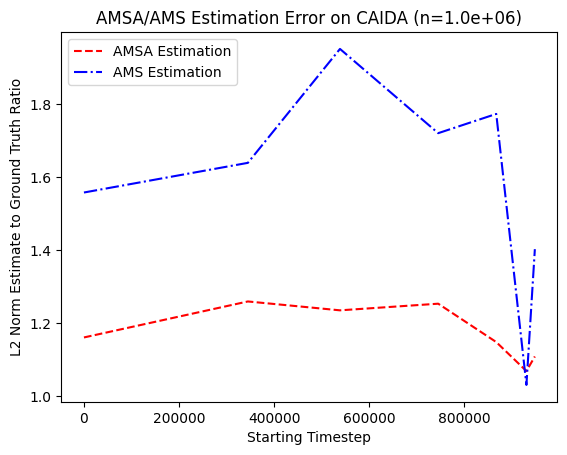

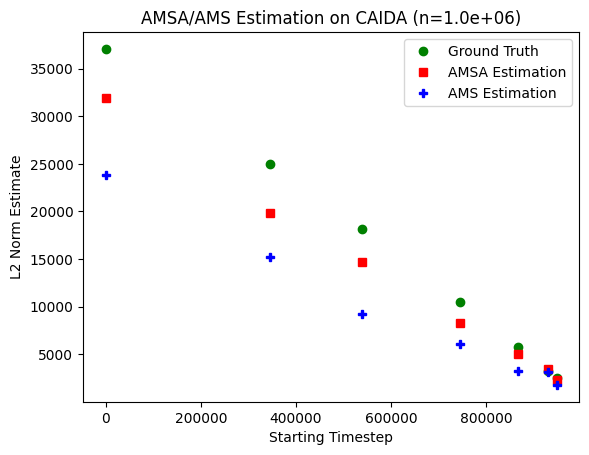

In [45]:
import matplotlib.pyplot as plt
 
indices, est_amsa, est_ams, gts, err_amsa, err_ams = calculate_estimates(hist_ams, hist_amsa)
 
# plot the ratio
_, ax = plt.subplots()
ax.plot(indices[:-13], err_amsa[:-13], 'r--', label="AMSA Estimation")
ax.plot(indices[:-13], err_ams[:-13], 'b-.', label="AMS Estimation")
ax.set_xlabel("Starting Timestep")
ax.set_ylabel("L2 Norm Estimate to Ground Truth Ratio")
ax.set_title(f"AMSA/AMS Estimation Error on CAIDA (n={m:.1e})")
ax.legend()

# plot the values
_, ax2 = plt.subplots()
ax2.plot(indices[:-13], gts[:-13], 'go', label="Ground Truth")
ax2.plot(indices[:-13], est_amsa[:-13], 'rs', label="AMSA Estimation")
ax2.plot(indices[:-13], est_ams[:-13], 'bP', label="AMS Estimation")
ax2.set_xlabel("Starting Timestep")
ax2.set_ylabel("L2 Norm Estimate")
ax2.set_title(f"AMSA/AMS Estimation on CAIDA (n={m:.1e})")
ax2.legend()

plt.show()

In [46]:
# provide tabular results
print("{0:>18}{1:>18}{2:>18}{3:>18}{4:>18}".format("Ground Truth",
                                                   "AMSA Estimate", 
                                                   "AMS Estimate", 
                                                   "AMSA Error Ratio", 
                                                   "AMS Error Ratio"))
for gt, amsa_est, ams_est, amsa_err, ams_err in zip(gts[:-13], 
                                                    est_amsa[:-13], 
                                                    est_ams[:-13], 
                                                    err_amsa[:-13], 
                                                    err_ams[:-13]):
    print("{0:>18.3f}{1:>18.3f}{2:>18.3f}{3:>18.3f}{4:>18.3f}".format(gt,
                                                   amsa_est, 
                                                   ams_est, 
                                                   amsa_err, 
                                                   ams_err))

      Ground Truth     AMSA Estimate      AMS Estimate  AMSA Error Ratio   AMS Error Ratio
         37057.324         31924.713         23792.000             1.161             1.558
         24954.889         19816.353         15228.000             1.259             1.639
         18107.665         14661.934          9283.000             1.235             1.951
         10450.772          8339.365          6076.000             1.253             1.720
          5766.540          5022.549          3253.000             1.148             1.773
          3209.988          3430.702          3114.000             1.069             1.031
          2520.172          2273.159          1797.000             1.109             1.402
